In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

blobs = pd.read_csv(r"D:\data_mining\tuan6\data.csv")
colnames = list(blobs.columns[1:-1])
blobs.head()

,ID,x,y,cluster
0,0,24.412,32.932,2
1,1,35.190,12.189,1
2,2,26.288,41.718,2
3,3,0.376,15.506,0
4,4,26.116,3.963,1


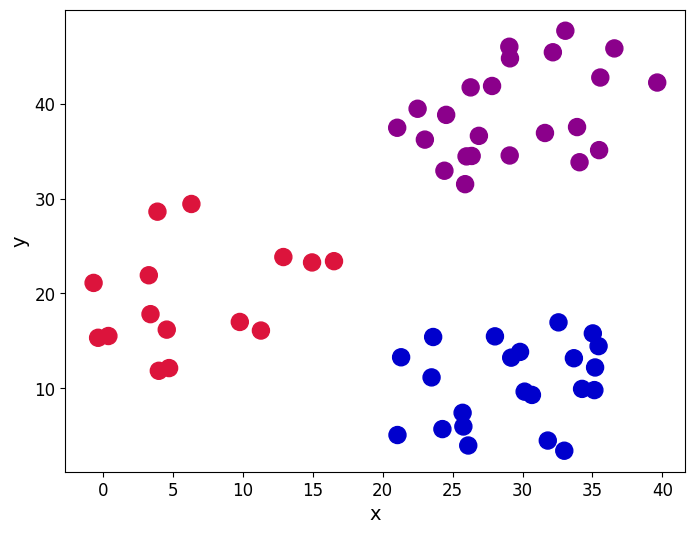

In [18]:
customcmap = ListedColormap(["crimson", "mediumblue", "darkmagenta"])
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(x=blobs['x'], y=blobs['y'], s=150,
            c=blobs['cluster'].astype('category'),
            cmap= customcmap)

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [20]:
def initiate_centroids(k, dset):
    centroids = dset.sample(k)
    return centroids

np.random.seed(42)
k = 3
df = blobs[['x', 'y']]
centroids = initiate_centroids(k, df)
centroids

,x,y
0,24.412,32.932
5,25.893,31.515
36,26.878,36.609


In [30]:
def rsserr(a, b):
    return np.sum(np.square(a - b))

In [25]:
for i, centroid in enumerate(range(centroids.shape[0])):
    err = rsserr(centroids.iloc[centroid, :], df.iloc[36, :])
    print('Error for centroid {0}: {1:.2f}'.format(i, err))

Error for centroid 0: 19.60
Error for centroid 1: 26.92
Error for centroid 2: 0.00


In [37]:
def centroid_assignation(dset, centroids):
    k = centroids.shape[0]
    n = dset.shape[0]
    assignation = []
    assign_errors = []
    for obs in range(n):
        #Estimate error
        all_errors = np.array([])
        for centroid in range(k):
            err = rsserr(centroids.iloc[centroid, :], dset.iloc[obs, :])
            all_errors = np.append(all_errors, err)
        nearest_centroid = np.where(all_errors==np.amin(all_errors))[0].tolist()[0]
        nearest_centroid_error = np.amin(all_errors)
        assignation.append(nearest_centroid)
        assign_errors.append(nearest_centroid_error)
    return assignation, assign_errors

In [38]:
df['centroid'], df['error'] = centroid_assignation(df, centroids)
df.head()

,x,y,centroid,error
0,24.412,32.932,0,0.000000
1,35.190,12.189,1,459.928485
2,26.288,41.718,2,26.449981
3,0.376,15.506,0,881.394772
4,26.116,3.963,1,759.162433


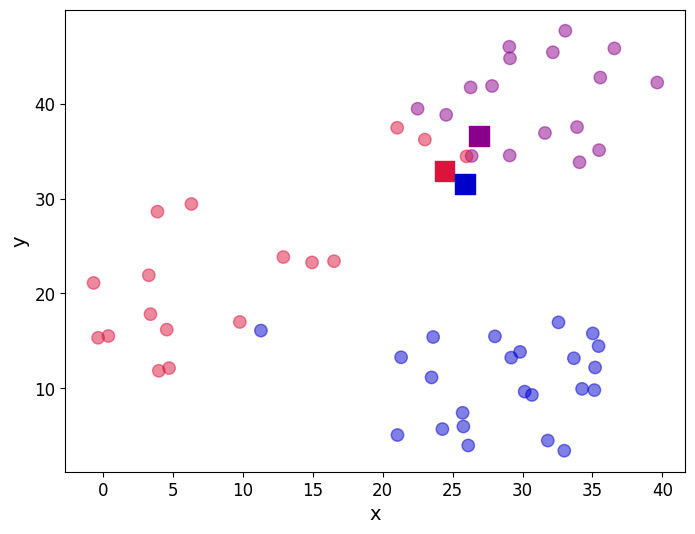

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], marker= 'o',
            c=df['centroid'].astype('category'),
            cmap= customcmap, s=80, alpha=0.5)

plt.scatter(centroids.iloc[:, 0], centroids.iloc[:, 1],
            marker= 's', s=200, c=[0, 1, 2],
            cmap= customcmap)

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [50]:
print("The total error ís {0:.2f}".format(df['error'].sum()))

The total error ís 2762.56


In [41]:
centroids = df.groupby('centroid').agg('mean').loc[:, colnames].reset_index(drop = True)
centroids

,x,y
0,9.889444,23.242611
1,28.435750,11.546250
2,30.759333,40.311167


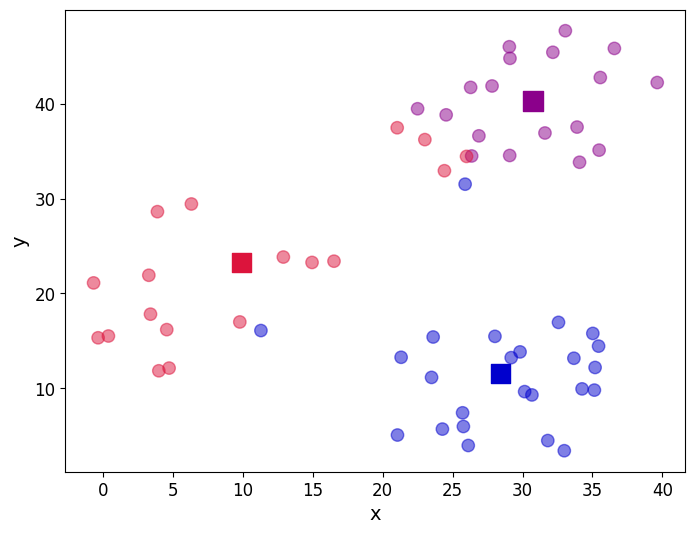

In [42]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], marker= 'o',
            c=df['centroid'].astype('category'),
            cmap= customcmap, s=80, alpha=0.5)

plt.scatter(centroids.iloc[:, 0], centroids.iloc[:, 1],
            marker= 's', s=200, c=[0, 1, 2],
            cmap= customcmap)

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
def kmeans(dset, k=2, tol=1e-4):
    working_dset = dset.copy()

    err = []
    goahead = True
    j = 0

    centroids = initiate_centroids(k , dset)

    while(goahead):
        working_dset['centroid'], j_err = centroid_assignation(working_dset, centroids)
        err.append(sum(j_err))

        centroids = working_dset.groupby('centroid').agg('mean').reset_index(drop = True)

        if j > 0:
            if err[j - 1] - err[j] <= tol:
                goahead = False
        j += 1

    working_dset['centroid'], j_err = centroid_assignation(working_dset, centroids)
    centroids = working_dset.groupby('centroid').agg('mean').reset_index(drop = True)
    return working_dset['centroid'], j_err, centroids

In [44]:
np.random.seed(42)
df['centroid'], df['error'], centroids = kmeans(df[['x', 'y']], 3)
df.head()

,x,y,centroid,error
0,24.412,32.932,2,61.380524
1,35.190,12.189,1,37.415091
2,26.288,41.718,2,16.216075
3,0.376,15.506,0,51.798518
4,26.116,3.963,1,52.188602


In [45]:
centroids

,x,y
0,6.322867,19.559800
1,29.330864,10.432409
2,29.304957,39.050783


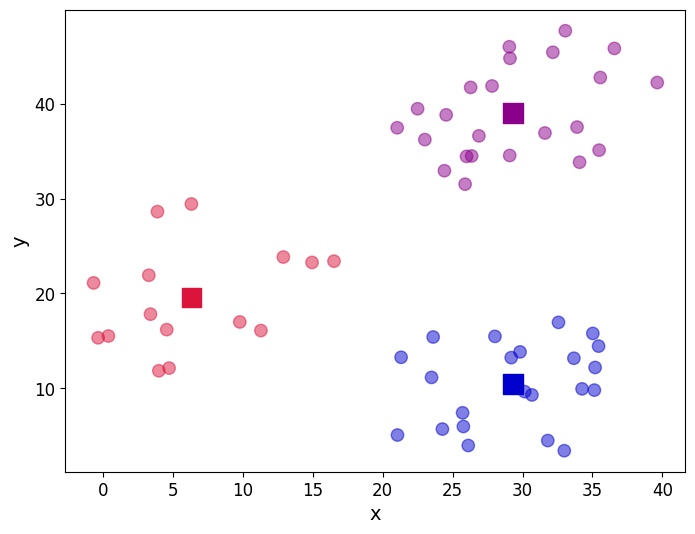

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], marker= 'o',
            c=df['centroid'].astype('category'),
            cmap= customcmap, s=80, alpha=0.5)

plt.scatter(centroids.iloc[:, 0], centroids.iloc[:, 1],
            marker= 's', s=200, c=[0, 1, 2],
            cmap= customcmap)

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

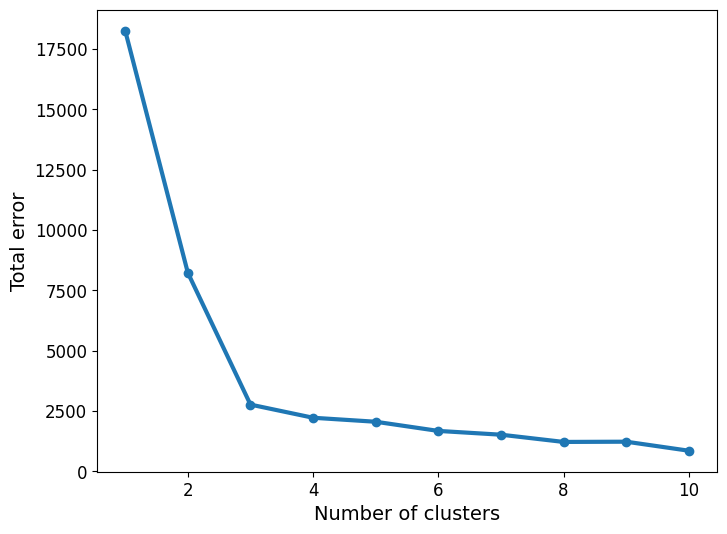

In [48]:
err_total = []
n = 10
df_elbow = blobs[['x', 'y']]
for i in range(n):
    _, my_errs, _ = kmeans(df_elbow, i + 1)
    err_total.append(sum(my_errs))

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(range(1, n+1), err_total, linewidth=3, marker='o')

ax.set_xlabel(r'Number of clusters', fontsize=14)
ax.set_ylabel(r'Total error', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()